In [15]:
import math
from math import ceil, sqrt
from typing import List, Optional, Tuple, Dict, Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, Circle
from hydrax.utils.files import get_data_path
import pandas as pd
import pprint
from hydrax.utils.files import get_data_path



def extract_single_data(df):
    data = {}
    # data["state_cost"] = df["state_cost"].to_numpy()
    data["success"] = df["success"].to_numpy()
    data["state_error"] = df["state_error"].to_numpy()
    data["T_pos"] = np.array([eval(x) for x in df["qpos"]])[:, :3]
    data["ee_pos"] = np.array([eval(x) for x in df["ee_pos"]])
    data["control"] = np.array([eval(x) for x in df["control"]])
    return data

def extract_values(path, seeds, controllers):
    data: Dict[int, Dict[str, Dict[str, np.ndarray]]] = {}
    missing: list[str] = []

    for seed in seeds:
        data[seed] = {}
        for controller in controllers:
            file = path / f"{controller}/seed_{seed}.csv"
            if not file.exists():
                missing.append(str(file))
                continue
            df = pd.read_csv(file)
            data[seed][controller] = extract_single_data(df)

    if missing:
        print("[plot_seeds] Skipped missing files:\n  - " + "\n  - ".join(missing))
    # Safety: filter seeds with at least one controller present
    seeds_present = [s for s in seeds if len(data.get(s, {})) > 0]
    if not seeds_present:
        raise FileNotFoundError("No seed data found. Check paths and filenames.")
    return data



#### Plot T Shapes

In [16]:
def rotmat(theta: float) -> np.ndarray:
    c, s = math.cos(theta), math.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

def rectangle_corners(center_xy: Tuple[float, float], width: float, height: float, yaw: float) -> np.ndarray:
    cx, cy = center_xy
    R = rotmat(yaw)
    hw, hh = width / 2.0, height / 2.0
    local = np.array([
        [-hw, -hh],
        [ hw, -hh],
        [ hw,  hh],
        [-hw,  hh],
    ])
    world = (local @ R.T) + np.array([cx, cy])
    return world

def t_shape_polys(x: float, y: float, yaw: float,
                  stem_w: float, stem_h: float,
                  head_w: float, head_h: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build the two polygons (stem and head) of a T-shape placed at pose (x, y, yaw).

    Conventions:
    - The T's bounding box center is the reference origin before pose transform.
    - Total height H = stem_h + head_h.
    - Stem is centered horizontally; its center at y = -head_h/2.
    - Head is centered horizontally; its center at y = +stem_h/2.
    """
    stem_center_local = np.array([0.0, -head_h / 2.0])
    head_center_local = np.array([0.0,  stem_h / 2.0])

    stem_center_world = (stem_center_local @ rotmat(yaw).T) + np.array([x, y])
    head_center_world = (head_center_local @ rotmat(yaw).T) + np.array([x, y])

    stem_poly = rectangle_corners(stem_center_world, stem_w, stem_h, yaw)
    head_poly = rectangle_corners(head_center_world, head_w, head_h, yaw)
    return stem_poly, head_poly

def plot_action_space(ax, xmin, xmax, ymin, ymax, show_grid: bool=False, grid_dx: float=0.25):
    ax.add_patch(Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, linewidth=1.5))
    if show_grid and grid_dx > 0:
        xv = np.arange(math.ceil(xmin / grid_dx) * grid_dx, xmax + 1e-9, grid_dx)
        yv = np.arange(math.ceil(ymin / grid_dx) * grid_dx, ymax + 1e-9, grid_dx)
        for xx in xv:
            ax.plot([xx, xx], [ymin, ymax], linewidth=0.4)
        for yy in yv:
            ax.plot([xmin, xmax], [yy, yy], linewidth=0.4)

def draw_t(ax, x, y, yaw_deg,
           stem_w, stem_h, head_w, head_h,
           face_alpha=0.25, edge_width=0.5, edge_style='solid',
           facecolor=None, edgecolor=None, label: Optional[str]=None):
    yaw = math.radians(yaw_deg)
    stem_poly, head_poly = t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h)

    poly_kwargs = dict(closed=True, alpha=face_alpha, edgecolor='none')
    if facecolor is not None:
        poly_kwargs['facecolor'] = facecolor

    stem_patch = Polygon(stem_poly, **poly_kwargs)
    head_patch = Polygon(head_poly,  **poly_kwargs)
    stem_patch.set_linestyle(edge_style)
    head_patch.set_linestyle(edge_style)
    stem_patch.set_linewidth(edge_width)
    head_patch.set_linewidth(edge_width)

    ax.add_patch(stem_patch)
    ax.add_patch(head_patch)

    if label:
        ax.text(x, y, label, ha='center', va='center')

    # Return all points for auto-limits
    return np.vstack([stem_poly, head_poly])

def draw_ee_start(ax, x, y, radius=0.03, edge_width=1.5, label: Optional[str]=None, color='blue', offset: float = 0.0):
    ax.scatter([x + offset], [y], s=5, color=color, alpha=0.5)


def set_nice_limits(ax, pts_list: List[np.ndarray], action_space: Optional[Tuple[float, float, float, float]]=None, margin=0.0, equal_axes=True):
    if pts_list:
        all_pts = np.vstack(pts_list)
        xmin_t, ymin_t = np.min(all_pts, axis=0) - margin
        xmax_t, ymax_t = np.max(all_pts, axis=0) + margin
    else:
        xmin_t, ymin_t, xmax_t, ymax_t = -1, -1, 1, 1

    if action_space is not None:
        xmin, xmax, ymin, ymax = action_space
        xmin = min(xmin, xmin_t)
        xmax = max(xmax, xmax_t)
        ymin = min(ymin, ymin_t)
        ymax = max(ymax, ymax_t)
    else:
        xmin, xmax, ymin, ymax = xmin_t, xmax_t, ymin_t, ymax_t  # note: swapped order fix below
        # Correct swapped order: we intended (xmin, xmax, ymin, ymax)
        xmin, xmax, ymin, ymax = xmin_t, xmax_t, ymin_t, ymax_t

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    if equal_axes:
        ax.set_aspect('equal', adjustable='box')

#### Plot Cost over Time

In [ ]:
def plot_state_error_grid(data, 
                          ax, 
                        #   legend_handles, 
                          controllers: List[str], 
                          seed: int, 
                          colors: Optional[List[str]],
                          linestyles: List[str],
                          smooth_window: int = 1):
    """
    Plot state error over time for each seed, comparing all controllers.

    Parameters
    ----------
    data : dict
        Nested dict like data[seed][controller]["state_error"] = np.array(...)
    titles : dict or None
        Optional mapping seed -> title string for each subplot.
    smooth_window : int or None
        Optional simple moving-average window (in steps) to smooth curves.
    """


    handles = []
    labels = []

    for j, controller in enumerate(controllers):
        if controller not in data[seed]:
            continue  # skip if missing for this seed

        err = data[seed][controller]["state_error"] 
        # Build x-axis (time index)
        t = np.arange(len(err))

        # Optional smoothing
        if smooth_window and smooth_window > 1:
            k = int(smooth_window)
            if k > 1 and k < len(err):
                kernel = np.ones(k) / k
                err = np.convolve(err, kernel, mode='valid')
                # align time after convolution
                t = np.arange(len(err))

        ls = linestyles[j % len(linestyles)]
        color = None if colors is None else colors[j % len(colors)]

        line, = ax.plot(t, err, linestyle=ls, label=controller, color=color)
        handles.append(line)
        labels.append(controller)

    ax.set_xlabel("Time step")
    ax.set_ylabel("State error (L2)" if handles else "State error")
    ax.grid(True, alpha=0.3)


In [ ]:
def plot_control_magnitudes(data, fig, ax, controllers, seed, colors, linestyles):
    
    pos = ax.get_position()      # get the position of the existing axis
    ax.remove()                  # remove the old (Cartesian) axis
    ax_polar = fig.add_axes(pos, projection='polar')
    for j, controller in enumerate(controllers):
        if controller not in data[seed]:
            continue  # skip if missing for this seed

        control = data[seed][controller]["control"] 
        control_magnitudes = np.linalg.norm(control, axis=1)
        control_angles = np.arctan2(control[:, 1], control[:, 0])
    

        # Plot
        ls = linestyles[j % len(linestyles)]
        color = None if colors is None else colors[j % len(colors)]
        for t, rad in zip(control_angles, control_magnitudes):
            ax.plot([t, t], [0, rad], color=color, alpha=0.4, linestyle=ls)  # line from origin to (t, r)

        # polar plot
        # ls = linestyles[j % len(linestyles)]
        # color = None if colors is None else colors[j % len(colors)]
        # ax_polar.plot(control_angles, control_magnitudes, linestyle=ls, label=controller, color=color, alpha=0.5)

In [53]:
def plot_data(path, seeds, controllers):

    data = extract_values(path, seeds, controllers)
    # Decide grid layout (roughly square)
    n = len(seeds)
    # A simple color/linestyle cycle
    linestyles = ['-', '--', '-.', ':']
    # Use Matplotlib’s default color cycle
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', None)
    
    fig, axs = plt.subplots(
        n, 3,
        figsize=(10, 3.5 * n),   # proportional scaling
        constrained_layout=True,
        squeeze=False, sharex=False, sharey=False
    )
    for i in range(n):
        plot_state_error_grid(data, axs[i, 0], controllers=controllers, seed=seeds[i], colors=colors, linestyles=linestyles)
        plot_control_magnitudes(data, fig, axs[i, 2], controllers=controllers, seed=seeds[i], colors=colors, linestyles=linestyles)

    # legend_handles = None
    # fig.legend(*legend_handles, loc='upper center', ncol=min(4, len(controllers)), frameon=False, bbox_to_anchor=(0.5, 1.02))


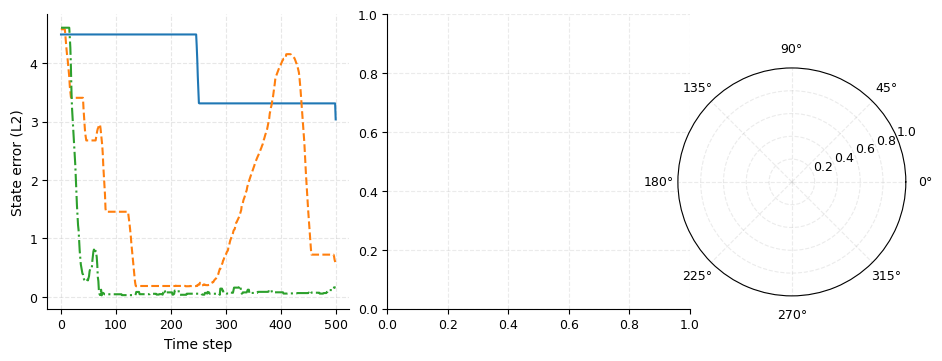

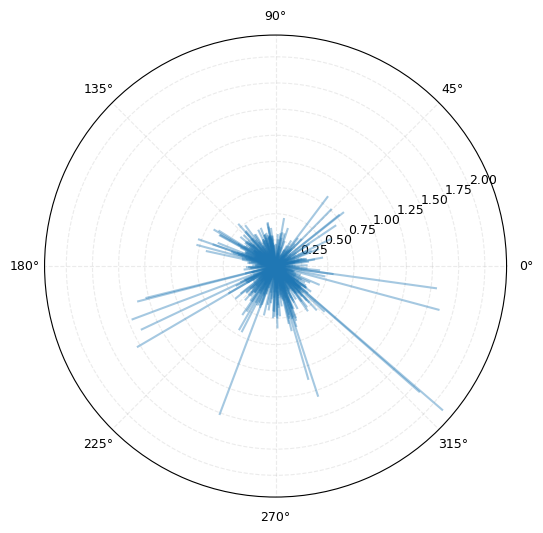

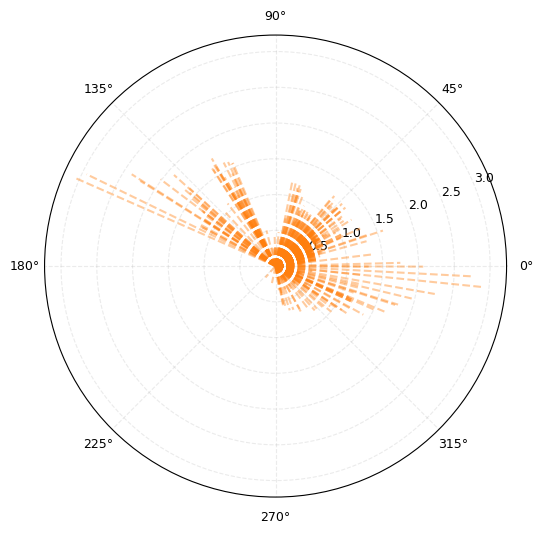

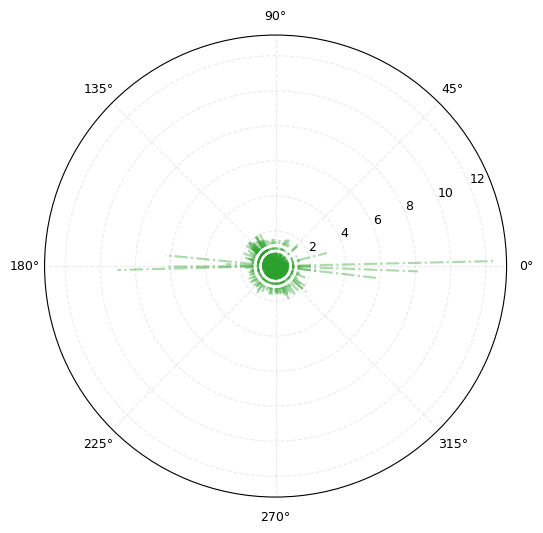

In [54]:
path = get_data_path() / "pushT_sim"
plot_data(path, [845545], ["mppi", "cem", "anmtp"])

In [ ]:


def plot_scene(
    ax,
    action_space: Optional[Tuple[float, float, float, float]],
    t_list: List[Dict[str, Any]],
    goal_t: Optional[Dict[str, Any]]=None,
    ee_starts: Optional[List[Dict[str, float]]]=None,
    show_grid: bool=False,
    color: Optional[str]=None,
    offset: float = 0.0,
):
    """
    Parameters
    ----------
    action_space : (xmin, xmax, ymin, ymax) or None
    t_list : list of T dicts, each with keys:
        {
          "x": float, "y": float, "yaw_deg": float,
          "stem_w": float, "stem_h": float,
          "head_w": float, "head_h": float,
          "label": Optional[str]
        }
    goal_t : optional single T dict (same schema as above).
    ee_starts : optional list of dicts with keys:
        { "x": float, "y": float, "r": float (optional), "label": Optional[str] }
    """
    pts_for_limits = []
    T = t_list[0]  # first T in color
    

    facecolor = "grey"
    edgecolor = "grey"
    pts = draw_t(
        ax,
        T["x"], T["y"], T["yaw_deg"],
        T["stem_w"], T["stem_h"],
        T["head_w"], T["head_h"],
        face_alpha=0.15, edge_width=0.5,
        facecolor=facecolor, edgecolor=edgecolor,
    )

    # Plot regular T’s
    # for i, T in enumerate(t_list or []):
    #     # first T in color
    #     if i == 0 and color is not None:
    #         facecolor = color
    #         edgecolor = color
    #     else:
    #         facecolor = "grey"
    #         edgecolor = "grey"
    #     pts = draw_t(
    #         ax,
    #         T["x"], T["y"], T["yaw_deg"],
    #         T["stem_w"], T["stem_h"],
    #         T["head_w"], T["head_h"],
    #         face_alpha=0.35, edge_width=0.5,
    #         facecolor=facecolor, edgecolor=edgecolor,
    #     )
    #     pts_for_limits.append(pts)

    # Plot goal T (styled differently)
    if goal_t is not None:
        pts = draw_t(
            ax,
            goal_t["x"], goal_t["y"], goal_t["yaw_deg"],
            goal_t["stem_w"], goal_t["stem_h"],
            goal_t["head_w"], goal_t["head_h"],
            face_alpha=0.20, 
            facecolor="green", edgecolor="green",
        )
        pts_for_limits.append(pts)

    # Plot end-effector start positions
    for i, ee in enumerate(ee_starts or []):
        r = ee.get("r", 0.03)
        draw_ee_start(ax, ee["x"], ee["y"], radius=r, edge_width=1.5, label=ee.get("label", f"EE{i}") , color=color or 'blue', offset=offset)



In [ ]:



    



from typing import Optional, Sequence, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter

def plot_seeds(
    seeds: Sequence[int],
    controllers: Sequence[str] = ("mppi", "cem"),
    error_smooth_window: Optional[int] = 1,
    *,
    figsize_per_row: float = 3.5,
    dpi: int = 140,
    title: Optional[str] = "PushT Simulation — Seeds Overview",
    save_path: Optional[str] = None,
    show_legend: bool = True,
    scene_limits: tuple = (-0.5, 0.5, -0.2, 0.8),
    offset: float = 0.0,
):
    """
    Plot state error, 2D scene, and control magnitude per seed with improved visuals.

    Parameters
    ----------
    seeds : sequence of int
        Seed identifiers to load.
    controllers : sequence of str, default ("mppi",)
        Controller names; each is expected to have CSVs at <data_root>/<controller>/seed_<seed>.csv.
    error_smooth_window : Optional[int], default 5
        Moving-average window for state error; set to None or <=1 to disable.
    figsize_per_row : float, default 4.2
        Height per seed row in inches.
    dpi : int, default 140
        Figure DPI.
    title : Optional[str]
        Figure suptitle; set to None to disable.
    save_path : Optional[str]
        If given, path to save the figure (e.g., "plots/pusht_overview.png").
    show_legend : bool, default True
        Whether to draw legends on the time-series axes.
    scene_limits : tuple (xmin, xmax, ymin, ymax)
        Axis limits passed to the scene plotter.
    """

    # --------- Style tweaks (clean, readable) ----------
    plt.rcParams.update({
        "axes.facecolor": "#ffffff",
        "figure.facecolor": "#ffffff",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "semibold",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
    })

    # Consistent colors per controller (fallback to tab10)
    tab10 = plt.get_cmap("tab10")
    color_map: Dict[str, str] = {
        ctrl: tab10(i % 10) for i, ctrl in enumerate(controllers)
    }

    # --------- Load data ----------
    data: Dict[int, Dict[str, Dict[str, np.ndarray]]] = {}
    path = get_data_path() / "pushT_sim"
    missing: list[str] = []

    for seed in seeds:
        data[seed] = {}
        for controller in controllers:
            file = path / f"{controller}/seed_{seed}.csv"
            if not file.exists():
                missing.append(str(file))
                continue
            df = pd.read_csv(file)
            data[seed][controller] = extract_values(df)

    if missing:
        print("[plot_seeds] Skipped missing files:\n  - " + "\n  - ".join(missing))
    # Safety: filter seeds with at least one controller present
    seeds_present = [s for s in seeds if len(data.get(s, {})) > 0]
    if not seeds_present:
        raise FileNotFoundError("No seed data found. Check paths and filenames.")

    # --------- Figure & axes ----------
    n_rows = len(seeds_present)
    fig, axs = plt.subplots(
        n_rows, 3,
        figsize=(10, 3.5 * n_rows),   # proportional scaling
        dpi=dpi,
        constrained_layout=True,
        gridspec_kw=dict(width_ratios=[1, 1, 1], height_ratios=[1]*n_rows)
    )
        # Ensure axs is always 2D
    axs = np.atleast_2d(axs)

    # Make all subplots visually the same size box
    for ax_row in axs:
        for ax in ax_row:
            ax.set_box_aspect(1)  # force each axes to be a square box
    legend_handles = None
    for row_i, seed in enumerate(seeds_present):
        
        handles = []
        labels = []

        # ------------- (1) State error over time -------------
        ax_err = axs[row_i, 0]
        ax_err.set_xlabel("Time step")
        ax_err.set_ylabel("State error")

        for controller in data[seed].keys():
            
            if "state_error" not in data[seed][controller]:
                continue
            err = np.asarray(data[seed][controller]["state_error"]).astype(float)
            t = np.arange(len(err))

            # Optional smoothing (moving average, 'same' length)
            if error_smooth_window and error_smooth_window > 1:
                k = int(error_smooth_window)
                if 1 < k <= len(err):
                    kernel = np.ones(k, dtype=float) / k
                    err_sm = np.convolve(err, kernel, mode="same")
                else:
                    err_sm = err
            else:
                err_sm = err

            ax_err.plot(
                t, err_sm,
                label=controller,
                color=color_map.get(controller, None),
                linewidth=1,
            )
            if legend_handles is None and handles:
                legend_handles = (handles, labels)


        # ------------- (2) Scene / trajectory -------------
        ax_scene = axs[row_i, 1]
        # Build inputs for plot_scene
        for controller in data[seed].keys():
            if ("T_pos" not in data[seed][controller]) or ("ee_pos" not in data[seed][controller]):
                continue

            t_list = [
                dict(
                    x=pos[0], y=pos[1]+0.4, yaw_deg=pos[2],
                    stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
                    color=color_map.get(controller, None),  # if your plotter supports it
                )
                for pos in data[seed][controller]["T_pos"]
            ]
            goal_t = dict(
                x=0.0, y=0.4, yaw_deg=0.0,
                stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05
            )
            ee_starts = [
                dict(x=pos[1], y=pos[0])
                for pos in data[seed][controller]["ee_pos"]
            ]

            # Render once per controller; if your plotter can't color by item,
            # it will still look better due to cleaned axis & limits below.
            plot_scene(
                ax_scene,
                action_space=scene_limits,
                t_list=t_list,
                goal_t=goal_t,
                ee_starts=ee_starts,
                color=color_map.get(controller, None),
                offset=offset,
            )
        ax_scene.set_xlim(scene_limits[0], scene_limits[1])
        ax_scene.set_ylim(scene_limits[2], scene_limits[3])
        # remove axis
        ax_scene.axis('off')
       

        # ------------- (3) Control magnitude -------------
        ax_u = axs[row_i, 2]
        ax_u.set_xlabel("Time step")
        ax_u.set_ylabel("‖u‖")

        for controller in data[seed].keys():
            if "control" not in data[seed][controller]:
                continue
            U = np.asarray(data[seed][controller]["control"])
            if U.ndim == 1:
                control_mag = np.abs(U)
            else:
                control_mag = np.linalg.norm(U, axis=1)
            t_u = np.arange(control_mag.shape[0])

            ax_u.plot(
                t_u, control_mag,
                label=controller,
                color=color_map.get(controller, None),
                linewidth=2,
            )
    if legend_handles:
        fig.legend(*legend_handles, loc='upper center', ncol=min(4, len(controllers)), frameon=False, bbox_to_anchor=(0.5, 1.02))
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        print(f"[plot_seeds] Saved figure to: {save_path}")

    return fig, axs


(<Figure size 1400x490 with 3 Axes>,
 array([[<Axes: xlabel='Time step', ylabel='State error'>, <Axes: >,
         <Axes: xlabel='Time step', ylabel='‖u‖'>]], dtype=object))

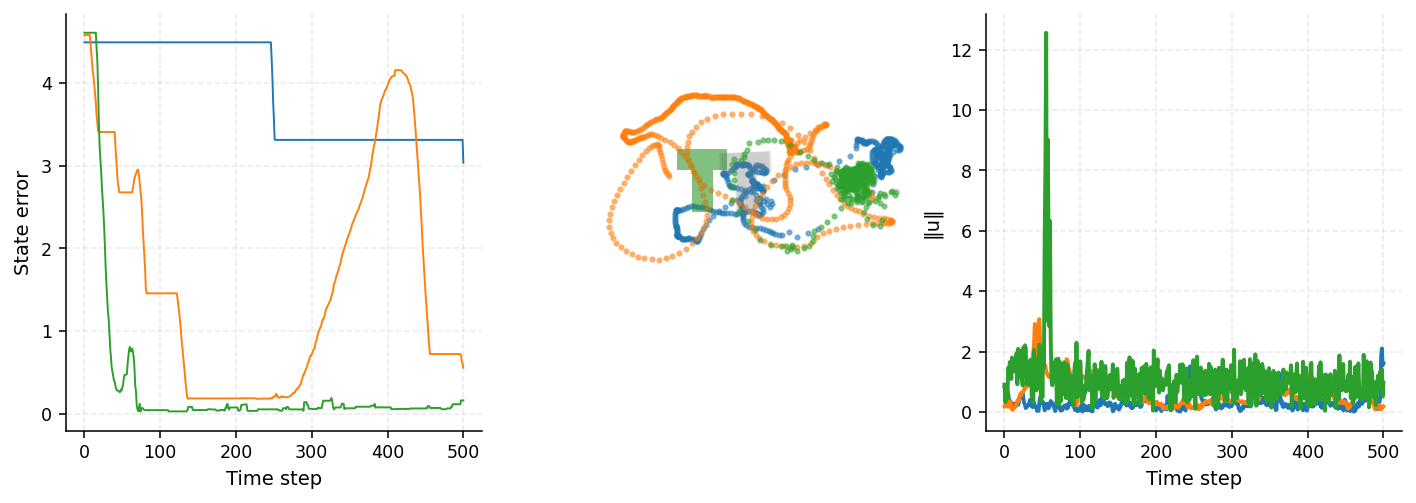

In [14]:
plot_seeds(seeds=[845545], controllers=["mppi", "cem", "anmtp"], offset=0.4)